In [28]:
import pandas as pd
import networkx as nx
import numpy as np

# NetworkX

In [29]:
df = pd.read_csv('enron_weighted_edges.csv')

x = df['Source'].to_list()
y = df['Target'].to_list()
weight = df['Weight'].to_list()

#edge list
edges=[]

for i in range(len(x)):
    edges.append((x[i],y[i],weight[i]))

In [30]:
G = nx.DiGraph()

nodes = np.arange(1,56955,1)

G.add_nodes_from(nodes)
G.add_weighted_edges_from(edges)

Network Summary

In [31]:
print('No. of nodes in the graph: ', G.order())
print('No. of edges in the graph: ',G.number_of_edges())
print('Network density: ',nx.density(G))
print('Is directed? ',G.is_directed())

No. of nodes in the graph:  56954
No. of edges in the graph:  228069
Network density:  7.031134762715852e-05
Is directed?  True


In [32]:
#self loop edge list

G.remove_edges_from(nx.selfloop_edges(G))

# Task 1

Degree Summary

In [33]:
# --- Degree ---
print(f"Average Degree = {( np.array([x[1] for x in G.degree(weight='weight')]).mean())}")
print(f"Average In-degree = {( np.array([x[1] for x in G.in_degree(weight='weight')]).mean())}")
print(f"Average Out-degree = {( np.array([x[1] for x in G.out_degree(weight='weight')]).mean())}\n")

# --- In-Degree ---
in_degrees = dict(G.in_degree())



max_in_node = max(in_degrees, key=in_degrees.get)
min_in_node = min(in_degrees, key=in_degrees.get)

# --- Out-Degree ---
out_degrees = dict(G.out_degree())

max_out_node = max(out_degrees, key=out_degrees.get)
min_out_node = min(out_degrees, key=out_degrees.get)

# --- Print Results ---
print(f"Maximum In-Degree Node: {max_in_node} with in-degree: {in_degrees[max_in_node]}")
print(f"Minimum In-Degree Node: {min_in_node} with in-degree: {in_degrees[min_in_node]}\n")

print(f"Maximum Out-Degree Node:{max_out_node} with out-degree: {out_degrees[max_out_node]}")
print(f"Minimum Out-Degree Node: {min_out_node} with out-degree:  {out_degrees[min_out_node]}")



Average Degree = 33.98296871159181
Average In-degree = 16.991484355795905
Average Out-degree = 16.991484355795905

Maximum In-Degree Node: 3266 with in-degree: 763
Minimum In-Degree Node: 70 with in-degree: 0

Maximum Out-Degree Node:1219 with out-degree: 1283
Minimum Out-Degree Node: 9 with out-degree:  0


Subgraph degree>=9

In [34]:
node_list = np.array([])

for x in G.degree():
    if x[1]>=10:
        node_list=np.append(node_list,int(x[0]))

G_sub = G.subgraph(node_list)

print('Sub graph of degree>=10:')
print(f'Number of nodes {G_sub.number_of_nodes()}')
print(f'Number of edges {G_sub.number_of_edges()}')
print(f"Average In-degree = {( np.array([x[1] for x in G_sub.in_degree(weight='weight')]).mean())}")
print(f"Average Out-degree = {( np.array([x[1] for x in G_sub.out_degree(weight='weight')]).mean())}\n")

Sub graph of degree>=10:
Number of nodes 6347
Number of edges 140501
Average In-degree = 119.20025208760045
Average Out-degree = 119.20025208760045



In [27]:
undirected_G_sub = G_sub.to_undirected()
avg_clustering = nx.average_clustering(undirected_G_sub)

print('\nAverage Clustering Coefficient: ',avg_clustering)

KeyboardInterrupt: 

In [ ]:
bc_G_sub = nx.betweenness_centrality(G_sub)

sorted_bc = sorted(bc_G_sub.items(), key=lambda x:x[1], reverse=True)

print("\nTop 10 Betweenness Centrality Nodes:")
for node,score in enumerate(sorted_bc[:10],1):
    print(node,score)


Top 10 Betweenness Centrality Nodes:
1 (np.float64(585.0), 0.07265345486352157)
2 (np.float64(3266.0), 0.044833554753539465)
3 (np.float64(1219.0), 0.03502791338364564)
4 (np.float64(5556.0), 0.03416420950107155)
5 (np.float64(4377.0), 0.03110653670581936)
6 (np.float64(4390.0), 0.028592138536407588)
7 (np.float64(4404.0), 0.02629918853302686)
8 (np.float64(3207.0), 0.021458529707177845)
9 (np.float64(1.0), 0.01756690332770357)
10 (np.float64(3631.0), 0.017055908551884637)


In [ ]:
cc_G_sub = nx.closeness_centrality(G_sub)

sorted_cc = sorted(cc_G_sub.items(), key=lambda x:x[1], reverse=True)

print("\nTop 10 Closeness Centrality Nodes:")
for node, score in enumerate(sorted_cc[:10],1):
    print(node,score)


Top 10 Closeness Centrality Nodes:
1 (np.float64(1070.0), 0.2990389371255153)
2 (np.float64(998.0), 0.297337685693119)
3 (np.float64(609.0), 0.29396409092720605)
4 (np.float64(4377.0), 0.2937931484436275)
5 (np.float64(3207.0), 0.29370775173348984)
6 (np.float64(521.0), 0.29212274314747505)
7 (np.float64(925.0), 0.28966628816448625)
8 (np.float64(1406.0), 0.28823406918715877)
9 (np.float64(3266.0), 0.2871691649906545)
10 (np.float64(1393.0), 0.28689737891740946)


In [ ]:
pos = nx.spring_layout(G_sub.to_undirected(), k=0.15, iterations=20)

In [ ]:
sorted_bc = sorted(bc_G_sub.items(), key=lambda x: x[1], reverse=True)[:100]
sorted_cc = sorted(cc_G_sub.items(), key=lambda x: x[1], reverse=True)[:100]

bc_nodes = [node for node, score in sorted_bc]
bc_sizes = [5000 * score for node, score in sorted_bc]

cc_nodes = [node for node, score in sorted_cc]
cc_sizes = [5000 * score for node, score in sorted_cc]


labels_bc = {node: node for node in bc_nodes}
labels_cc = {node: node for node in cc_nodes}

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Asus\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


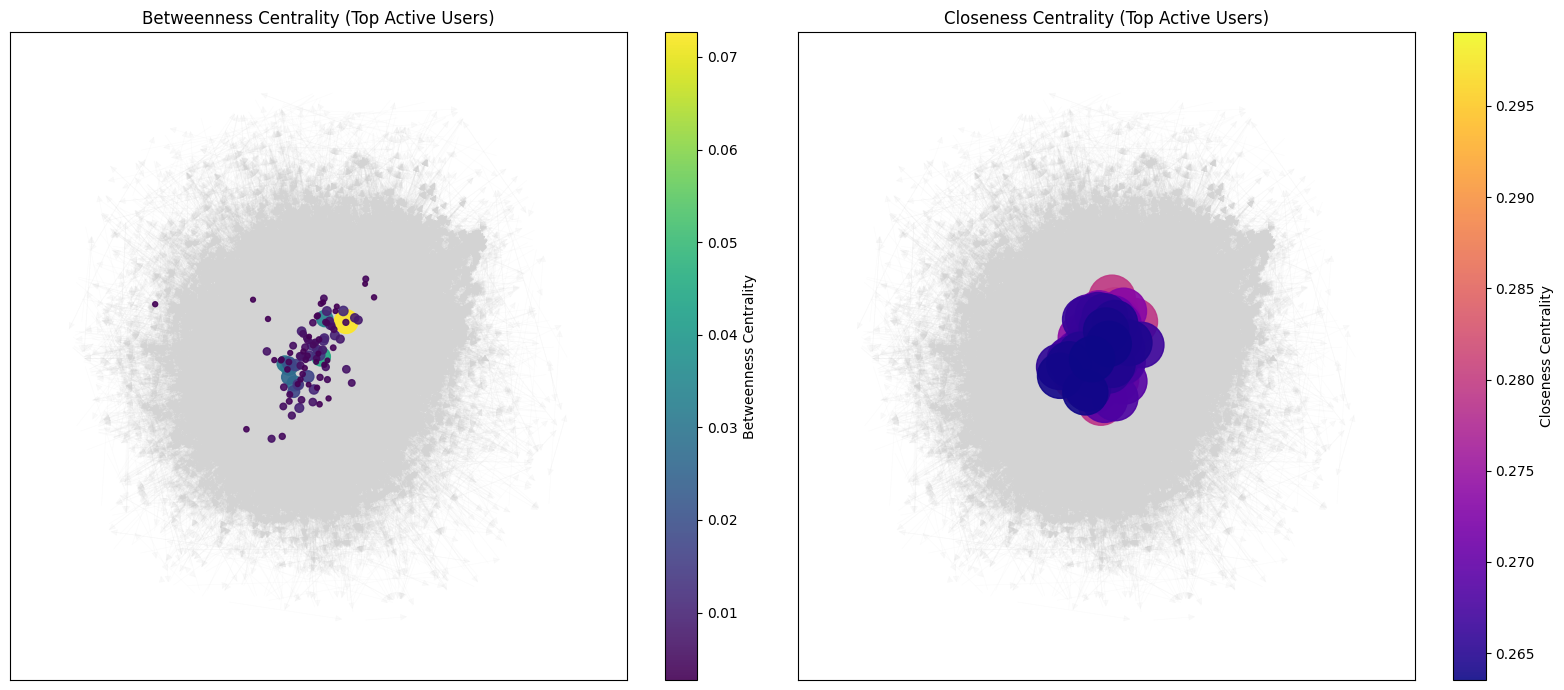

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

# ---------- Betweenness Centrality ----------
axes[0].set_title("Betweenness Centrality (Top Active Users)")

bc_values = np.array(bc_sizes) / 5000  # get original centrality values
bc_norm = mcolors.Normalize(vmin=min(bc_values), vmax=max(bc_values))

nodes_bc = nx.draw_networkx_nodes(
    G_sub,
    pos,
    nodelist=bc_nodes,
    node_size=[4000 * v for v in bc_values],  # better scaling
    node_color=bc_values,
    cmap=plt.cm.viridis,
    alpha=0.9,
    ax=axes[0]
)

nx.draw_networkx_edges(G_sub, pos, alpha=0.1, width=0.4, edge_color='lightgray', ax=axes[0])
# Removed labels

cbar1 = plt.colorbar(nodes_bc, ax=axes[0])
cbar1.set_label("Betweenness Centrality")


# ---------- Closeness Centrality ----------
axes[1].set_title("Closeness Centrality (Top Active Users)")

cc_values = np.array(cc_sizes) / 5000
cc_norm = mcolors.Normalize(vmin=min(cc_values), vmax=max(cc_values))

nodes_cc = nx.draw_networkx_nodes(
    G_sub,
    pos,
    nodelist=cc_nodes,
    node_size=[4000 * v for v in cc_values],
    node_color=cc_values,
    cmap=plt.cm.plasma,
    alpha=0.9,
    ax=axes[1]
)

nx.draw_networkx_edges(G_sub, pos, alpha=0.1, width=0.4, edge_color='lightgray', ax=axes[1])
# Removed labels

cbar2 = plt.colorbar(nodes_cc, ax=axes[1])
cbar2.set_label("Closeness Centrality")

plt.tight_layout()
plt.show()

TASK 3

In [35]:
import networkx as nx

G_sub = G.subgraph(node_list).to_undirected()


#finding the largest connected components of the network
Gcc = max(nx.connected_components(G_sub),key=len)
G_sub_cc = G_sub.subgraph(Gcc)

avg_clustering = nx.average_clustering(G_sub_cc)
real_path = nx.average_shortest_path_length(G_sub_cc)
real_degrees = np.array([d for _,d in G_sub_cc.degree()])

#generating random graphs
G_rand_set = []
Graphs = {}
n = 6347
m = 140501
p = m/ (n*(n-1))
for i in range(50):
    G_rand = nx.erdos_renyi_graph(n,p)

    if not nx.is_connected(G_rand):
        Gcc_rand = max(nx.connected_components(G_rand),key=len)
        G_rand_sub = G_rand.subgraph(Gcc_rand)
    else:
        G_rand_sub = G_rand

    clustering_coeff = nx.average_clustering(G_rand_sub)
    shortest_path = nx.average_shortest_path_length(G_rand_sub)
    degrees = np.array([d for _,d in G_rand_sub.degree()])

    deg_diff = np.mean(np.abs(np.sort(real_degrees)-np.sort(degrees[:len(real_degrees)])))

    score = ( 
        abs(clustering_coeff - avg_clustering)+ 
        abs(shortest_path - real_path) + 
        deg_diff
    )

    G_rand_set.append({"id" : i,
                       "score": score,
                       "clustering_coeff":clustering_coeff,
                       "path_length":shortest_path})
    Graphs[i] = G_rand_sub

In [36]:
import os
os.makedirs('top_graphs', exist_ok=True)

df = pd.DataFrame(G_rand_set)
df_sorted = df.sort_values('score')
top10 = df_sorted.head(10)

for i in top10["id"].astype(int):
    G = Graphs[i]
    nx.write_gexf(G, f'top_graphs/rand_graph_{i}.gexf')

# save top-10 stats
top10.to_csv('top_graphs/top10_stats.csv', index=False)
top10.to_json('top_graphs/top10_stats.json', orient='records', lines=False)

print("Real Network Statistics:")
print(f"Average Clustering Coefficient: {avg_clustering}")
print(f"Average Shortest Path Length: {real_path}")
print(f"Number of Nodes in Largest Component: {G_sub_cc.number_of_nodes()}")
print(f"Number of Edges in Largest Component: {G_sub_cc.number_of_edges()}")
print(f"Average Degree: {np.mean(real_degrees)}")
print()

# Print top 10 random networks statistics
print("Top 10 Random Networks Statistics (sorted by score):")
print(top10.to_string(index=False))

Real Network Statistics:
Average Clustering Coefficient: 0.3905279416267014
Average Shortest Path Length: 2.955343543445779
Number of Nodes in Largest Component: 6307
Number of Edges in Largest Component: 124550
Average Degree: 39.49579831932773

Top 10 Random Networks Statistics (sorted by score):
 id     score  clustering_coeff  path_length
 29 25.471464          0.003413     3.113420
 31 25.484745          0.003593     3.105794
 43 25.490383          0.003432     3.108575
 10 25.502963          0.003374     3.110790
 12 25.507562          0.003503     3.106799
 47 25.511994          0.003651     3.101865
  6 25.514583          0.003519     3.109079
 34 25.517493          0.003388     3.118834
 30 25.534577          0.003545     3.111816
 24 25.537423          0.003366     3.105604
